# Reading knee MRI DICOM into training-ready volumes

Working through one series on disk, then generalizing it. The helpers all live in
`dicom_tools.py` next to this notebook - this notebook is the explanation of *why*
they do what they do.

1. [What is actually inside a .dcm file](#1) - reading attributes with pydicom
2. [Geometry](#2) - orientation, pixel ratio, slice spacing
3. [Loading a series](#3) - why file order is a lie
4. [Standardizing](#4) - putting any incoming scan on one grid
5. [One sequence, loaded by hand](#5) - every knob, unrolled and annotated
6. [Scaling up](#6) - a manifest of the whole dataset


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

import dicom_tools as dt

# WSL reaches the Windows drive through /mnt/c, so C:\datasets\Knees is:
print(dt.DATA_ROOT, '->', dt.DATA_ROOT.exists())

studies = dt.list_studies()
print(f'{len(studies)} studies on disk')
series_paths = dt.list_series(studies[0])
for p in series_paths:
    print(' ', p.name[-12:], len(list(p.glob('*.dcm'))), 'slices')


/mnt/c/datasets/Knees -> True
1 studies on disk
  715412333772 22 slices
  927426543265 18 slices


  293168736174 16 slices
  147390476697 16 slices
  038670363546 22 slices


<a id="1"></a>
## 1. What is actually inside a .dcm file

A DICOM file is a **dictionary of tagged elements** plus one big binary blob of pixels.
Every element has:

| part | example | meaning |
|---|---|---|
| tag | `(0028,0010)` | (group, element) - the permanent identifier |
| keyword | `Rows` | human name pydicom exposes as an attribute |
| VR | `US` | value representation: how the bytes are typed |
| value | `512` | the payload |

The tag is what the standard guarantees; the keyword is pydicom's convenience layer
over it. Both address the same element.


In [2]:
f = sorted(series_paths[0].glob('*.dcm'))[0]
ds = pydicom.dcmread(f)

print(type(ds))
print()

# Three ways to reach the same element
print('by keyword :', ds.Rows)
print('by tag     :', ds[0x0028, 0x0010].value)
print('the element:', ds[0x0028, 0x0010])   # tag, name, VR and value all at once


<class 'pydicom.dataset.FileDataset'>

by keyword : 512
by tag     : 512
the element: (0028,0010) Rows                                US: 512


In [3]:
# An element object exposes its own metadata - useful when you meet an unfamiliar tag
elem = ds[0x0028, 0x0030]
print('tag     ', elem.tag)
print('keyword ', elem.keyword)
print('name    ', elem.name)
print('VR      ', elem.VR)
print('value   ', elem.value, type(elem.value))


tag      (0028,0030)
keyword  PixelSpacing
name     Pixel Spacing
VR       DS
value    [0.330078125, 0.330078125] <class 'pydicom.multival.MultiValue'>


### Value types: the trap that bites first

VR decides the Python type you get back, and it is not always what it looks like.

- `DS` (decimal string) -> `DSfloat`, a **subclass of float**. Arithmetic works directly.
- `IS` (integer string) -> `IS`, a subclass of int.
- `US` (unsigned short) -> plain `int`.
- `CS` (code string) -> `str`, from a fixed vocabulary like `'KNEE'` or `'FFS'`.
- Anything with multiple values -> `MultiValue`, a list-like container. `PixelSpacing` is one.

So `ds.SliceThickness * 2` quietly works and gives 6.8, but `ds.PixelSpacing * 2` raises -
pydicom 3 blocks arithmetic on `MultiValue` rather than doing something surprising. Index
into it first. The module casts with `float(...)` everywhere for exactly this reason: it
makes the single-value / multi-value distinction explicit instead of load-bearing.


In [4]:
print('SliceThickness   ', repr(ds.SliceThickness), '-> * 2 =', ds.SliceThickness * 2)
print('PixelSpacing     ', repr(ds.PixelSpacing), type(ds.PixelSpacing).__name__)

try:
    ds.PixelSpacing * 2
except TypeError as exc:
    print('  * 2             TypeError:', exc)

print('  indexed (right) ', float(ds.PixelSpacing[0]) * 2)
print()
print('Rows is a', type(ds.Rows), '| BodyPartExamined is a', type(ds.BodyPartExamined))


SliceThickness    '3.4' -> * 2 = 6.8
PixelSpacing      [0.330078125, 0.330078125] MultiValue
  * 2             TypeError: unsupported operand type(s) for *: 'MultiValue' and 'int'
  indexed (right)  0.66015625

Rows is a <class 'int'> | BodyPartExamined is a <class 'str'>


### Optional tags

Most tags are optional. Reaching for a missing one with attribute access raises
`AttributeError`, which is why the module uses `getattr(ds, 'Tag', default)` or
`ds.get()` everywhere geometry is not strictly required.

This dataset is anonymized, so a lot of the patient-level tags are stripped or blanked.
**`Laterality` is present but empty** - which matters, see the caveat in section 4.


In [5]:
print('present?      ', 'Laterality' in ds, '| value:', repr(ds.Laterality))
print('safe default  ', ds.get('PatientName', '<stripped>'))
print('getattr form  ', getattr(ds, 'InstitutionName', '<absent>'))
print()

# Search when you do not know the keyword
print('tags matching "spacing":', ds.dir('spacing'))
print('tags matching "echo"   :', ds.dir('echo'))


present?       True | value: ''
safe default   <stripped>
getattr form   <absent>

tags matching "spacing": ['PixelSpacing', 'SpacingBetweenSlices']
tags matching "echo"   : ['EchoNumbers', 'EchoTime', 'EchoTrainLength']


In [6]:
# The file_meta block is separate from the dataset - it describes the encoding,
# not the patient. TransferSyntaxUID tells you whether pixels are compressed.
print(ds.file_meta)


(0002,0000) File Meta Information Group Length  UL: 148
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian


In [7]:
# Walk everything. `ds` iterates over its elements in tag order.
for elem in ds:
    if elem.tag.group == 0x0018:          # the acquisition-parameters group
        print(f'{elem.tag}  {elem.name:<38} {elem.VR}  {elem.value}')


(0018,0010)  Contrast/Bolus Agent                   LO  
(0018,0015)  Body Part Examined                     CS  KNEE
(0018,0020)  Scanning Sequence                      CS  SE
(0018,0021)  Sequence Variant                       CS  SK
(0018,0022)  Scan Options                           CS  FS
(0018,0023)  MR Acquisition Type                    CS  2D
(0018,0050)  Slice Thickness                        DS  3.4
(0018,0080)  Repetition Time                        DS  4244.640625
(0018,0081)  Echo Time                              DS  22
(0018,0083)  Number of Averages                     DS  1
(0018,0084)  Imaging Frequency                      DS  63.87066
(0018,0086)  Echo Number(s)                         IS  1
(0018,0087)  Magnetic Field Strength                DS  1.5
(0018,0088)  Spacing Between Slices                 DS  4.635
(0018,0089)  Number of Phase Encoding Steps         IS  186
(0018,0091)  Echo Train Length                      IS  15
(0018,0093)  Percent Sampling        

### Pixels are lazy

`ds.PixelData` is raw bytes. `ds.pixel_array` decodes them into a numpy array on first
access - that decode is the expensive part of reading DICOM.

When you only need geometry (building a manifest, checking planes, counting slices), pass
`stop_before_pixels=True`. On these files it is only about 2x on wall clock - WSL reading
across `/mnt/c` dominates - but the memory difference is the real point: a few KB of
header against 512 KB of pixels per slice. Over ~22,000 series that is what makes a full
sweep practical.


In [8]:
import time

t0 = time.perf_counter(); full = pydicom.dcmread(f); _ = full.pixel_array
t_full = time.perf_counter() - t0
t0 = time.perf_counter(); hdr = pydicom.dcmread(f, stop_before_pixels=True)
t_hdr = time.perf_counter() - t0

print(f'full read + decode : {t_full*1000:7.2f} ms')
print(f'header only        : {t_hdr*1000:7.2f} ms   ({t_full/t_hdr:.0f}x faster)')
print()
print('PixelData bytes:', len(ds.PixelData), '-> array', ds.pixel_array.shape, ds.pixel_array.dtype)


full read + decode :   41.36 ms
header only        :   36.01 ms   (1x faster)

PixelData bytes: 524288 -> array (512, 512) uint16


### The tags that matter for this project

Out of ~70 elements in these files, these are the ones the pipeline reads:

| tag | keyword | why |
|---|---|---|
| (0020,0037) | `ImageOrientationPatient` | direction cosines -> plane, and mirroring |
| (0020,0032) | `ImagePositionPatient` | where the slice sits -> correct slice order |
| (0028,0030) | `PixelSpacing` | mm per pixel, row and column |
| (0018,0050) | `SliceThickness` | slab thickness (**not** the slice step) |
| (0018,0088) | `SpacingBetweenSlices` | centre-to-centre step, gaps included |
| (0028,0010/0011) | `Rows` / `Columns` | pixel grid |
| (0028,1052/1053) | `RescaleIntercept` / `RescaleSlope` | stored ints -> real values |
| (0028,1050/1051) | `WindowCenter` / `WindowWidth` | display hint only - do not train on it |
| (0018,0020..0023) | `ScanningSequence`, `ScanOptions`, ... | sequence type, fat-sat flags |
| (0018,0080/0081) | `RepetitionTime` / `EchoTime` | TR/TE - what the contrast actually is |
| (0020,000D/000E) | `Study` / `SeriesInstanceUID` | the join keys back to `train.csv` |


In [9]:
KEY_TAGS = ['ImageOrientationPatient', 'ImagePositionPatient', 'PixelSpacing',
            'SliceThickness', 'SpacingBetweenSlices', 'Rows', 'Columns',
            'RescaleSlope', 'RescaleIntercept', 'WindowCenter', 'WindowWidth',
            'ScanningSequence', 'ScanOptions', 'RepetitionTime', 'EchoTime',
            'MagneticFieldStrength', 'Manufacturer', 'SeriesDescription',
            'PatientPosition', 'BodyPartExamined', 'Laterality', 'InstanceNumber']

for t in KEY_TAGS:
    print(f'{t:<26} {ds.get(t, "<absent>")!r}')


ImageOrientationPatient    [-0.0334932804107, 0.99921125173568, 0.02133215218782, 0.05801957845687, 0.02325204573571, -0.9980446100234]
ImagePositionPatient       [-80.965252085414, -143.1194283448, 98.5467405450254]
PixelSpacing               [0.330078125, 0.330078125]
SliceThickness             '3.4'
SpacingBetweenSlices       '4.635'
Rows                       512
Columns                    512
RescaleSlope               '2.55507'
RescaleIntercept           '0'
WindowCenter               '959'
WindowWidth                '1667'
ScanningSequence           'SE'
ScanOptions                'FS'
RepetitionTime             '4244.640625'
EchoTime                   '22'
MagneticFieldStrength      '1.5'
Manufacturer               'Philips Healthcare'
SeriesDescription          'DP SPIR CS_SAG'
PatientPosition            'FFS'
BodyPartExamined           'KNEE'
Laterality                 ''
InstanceNumber             '5'


<a id="2"></a>
## 2. Geometry: orientation and pixel ratio

**There is no `Plane` tag.** `SeriesDescription` sometimes hints (`DP SPIR CS_SAG`) but it
is free text written by whoever set up the protocol - one series in this very study is
called `T1_TSE_CS` and names no plane at all. The plane has to come from geometry.

`ImageOrientationPatient` holds six numbers: the direction the **column index** advances
(first three) and the direction the **row index** advances (last three), as unit vectors
in patient coordinates. Their cross product is the slice normal - the direction the stack
advances - and whichever patient axis it points along names the plane.

Patient coordinates are **LPS**: `+x` -> patient Left, `+y` -> Posterior, `+z` -> Superior.


In [10]:
iop = np.asarray(ds.ImageOrientationPatient, float)
print('column direction (across a row) :', np.round(iop[:3], 3))
print('row direction    (down a column):', np.round(iop[3:], 3))
print('slice normal (cross product)    :', np.round(np.cross(iop[:3], iop[3:]), 3))
print()
print('dominant axis -> plane:', dt.detect_plane(ds))
print()
print('Note the normal is not exactly (-1,0,0) - the radiographer angled the slab a few')
print('degrees. That is why the rule is argmax(|normal|), not an equality test.')


column direction (across a row) : [-0.033  0.999  0.021]
row direction    (down a column): [ 0.058  0.023 -0.998]
slice normal (cross product)    : [-0.998 -0.032 -0.059]

dominant axis -> plane: Sagittal

Note the normal is not exactly (-1,0,0) - the radiographer angled the slab a few
degrees. That is why the rule is argmax(|normal|), not an equality test.


In [11]:
# Does the geometry rule agree with the plane labels Kaggle ships?
manifest = dt.build_manifest()
truth = pd.read_csv('../data/train_series.csv')

check = manifest.merge(truth, on=['StudyInstanceUID', 'SeriesInstanceUID'])
print(check[['plane', 'Anatomical_Plane', 'series_description', 'Fluid_Sensitive', 'Fat_Suppression']].to_string(index=False))
print()
print('agreement:', (check.plane == check.Anatomical_Plane).mean())


   plane Anatomical_Plane series_description  Fluid_Sensitive  Fat_Suppression
Sagittal         Sagittal     DP SPIR CS_SAG                1                1
   Axial            Axial        STIR CS_ AX                1                1
 Coronal          Coronal          T1_TSE_CS                0                0
 Coronal          Coronal        DP SPAIR_CS                1                1
Sagittal         Sagittal          DP CS_SAG                0                0

agreement: 1.0


### Pixel ratio

Two different things get called "the pixel ratio", and both matter:

**In-plane aspect** = `PixelSpacing[0] / PixelSpacing[1]`. Here it is exactly 1.0 - square
pixels - so no aspect correction is needed. Do not assume it; check it per series.

**Through-plane anisotropy** = slice step / in-plane spacing. This is the big one. The
sagittal series is 0.33mm in plane and 4.63mm between slices - a voxel **14x longer**
than it is wide. A knee volume is nowhere near isotropic, which is why the pipeline
resamples in-plane only and leaves the slice axis alone.

And note the trap: `SliceThickness` is 3.4mm but the actual step is 4.635mm. The
difference is a 1.2mm gap between slabs. Measure the step from `ImagePositionPatient`,
never from `SliceThickness`.


In [12]:
hdrs = dt.read_headers(series_paths[0])
hdrs, positions = dt.sort_by_position(hdrs)
h = hdrs[0]

row_mm, col_mm = float(h.PixelSpacing[0]), float(h.PixelSpacing[1])
step = dt.slice_spacing(positions, hdrs)

print(f'in-plane        : {row_mm:.4f} x {col_mm:.4f} mm   aspect {row_mm/col_mm:.3f}')
print(f'slice thickness : {float(h.SliceThickness):.3f} mm  (tag)')
print(f'slice step      : {step:.3f} mm  (measured from positions)')
print(f'gap             : {step - float(h.SliceThickness):.3f} mm')
print(f'anisotropy      : {step/row_mm:.1f}x')
print()
print('per-slice positions along the normal (mm):')
print(np.round(positions, 2))
print('deltas:', np.round(np.diff(positions), 4))


in-plane        : 0.3301 x 0.3301 mm   aspect 1.000
slice thickness : 3.400 mm  (tag)
slice step      : 4.635 mm  (measured from positions)
gap             : 1.235 mm
anisotropy      : 14.0x

per-slice positions along the normal (mm):
[ 61.06  65.7   70.33  74.97  79.6   84.24  88.87  93.5   98.14 102.77
 107.41 112.04 116.68 121.31 125.95 130.58 135.22 139.85 144.48 149.12
 153.75 158.39]
deltas: [4.6345 4.6346 4.6345 4.6346 4.6345 4.6346 4.6345 4.6345 4.6346 4.6345
 4.6346 4.6345 4.6346 4.6345 4.6345 4.6346 4.6346 4.6345 4.6346 4.6346
 4.6346]


<a id="3"></a>
## 3. Loading a series

**Filename order is meaningless** - filenames are random SOP Instance UIDs, so sorting the
directory gives you slices in scrambled anatomical order. Run the cell below and look at
the first column: `sorted(glob)` hands back InstanceNumber 5, 10, 3, 2, 9, ...

`InstanceNumber` is the obvious fix and it is correct *for this series*. But it is a
counter the scanner assigns, not a geometric fact - it breaks on multi-echo series, where
several slices share a position, and there is nothing in the file that promises it follows
anatomy. The reliable ordering is physical: project each slice's `ImagePositionPatient`
onto the slice normal and sort by that. That is what `sort_by_position` does, and the
evenly-spaced `position_mm` column is the proof it worked.


In [13]:
raw_files = sorted(series_paths[0].glob('*.dcm'))
by_name = [pydicom.dcmread(p, stop_before_pixels=True) for p in raw_files]

cmp = pd.DataFrame({
    'instance_by_filename': [int(x.InstanceNumber) for x in by_name],
    'instance_by_position': [int(x.InstanceNumber) for x in hdrs],
    'position_mm': np.round(positions, 2),
})
print(cmp.to_string(index=False))
print()
print('filename order matches anatomy? ',
      (cmp.instance_by_filename == cmp.instance_by_position).all())
print('InstanceNumber matches anatomy? ',
      (cmp.instance_by_position.values == np.arange(1, len(cmp) + 1)).all(),
      ' <- true here, but not guaranteed')


 instance_by_filename  instance_by_position  position_mm
                    5                     1        61.06
                   10                     2        65.70
                    3                     3        70.33
                    2                     4        74.97
                    9                     5        79.60
                   12                     6        84.24
                   13                     7        88.87
                   16                     8        93.50
                   19                     9        98.14
                   14                    10       102.77
                   18                    11       107.41
                   22                    12       112.04
                    7                    13       116.68
                    8                    14       121.31
                   20                    15       125.95
                   15                    16       130.58
                   21          

#### Is this true of every series, or just this one?

Worth checking rather than assuming. Across all five series of this study: the filename
order is scrambled every time, and `InstanceNumber` happens to track anatomy every time.

So the data is not "out of order" - the scanner numbered the slices correctly. What is out
of order is the *directory listing*, because the filenames are content-free UIDs. Sorting
by position is the version that stays correct when a multi-echo series turns up.


In [14]:
for p in series_paths:
    hs = [pydicom.dcmread(f, stop_before_pixels=True) for f in sorted(p.glob('*.dcm'))]
    hs_sorted, _ = dt.sort_by_position(hs)
    by_file = [int(x.InstanceNumber) for x in hs]
    by_pos  = [int(x.InstanceNumber) for x in hs_sorted]
    print(f'{p.name[-12:]}  {dt.detect_plane(hs[0]):<9} '
          f'filename order ok: {str(by_file == by_pos):<5} '
          f'InstanceNumber ok: {str(by_pos == list(range(1, len(hs) + 1))):<5} '
          f'| filename order starts {by_file[:6]}')


715412333772  Sagittal  filename order ok: False InstanceNumber ok: True  | filename order starts [5, 10, 3, 2, 9, 12]
927426543265  Axial     filename order ok: False InstanceNumber ok: True  | filename order starts [14, 13, 2, 15, 4, 3]


293168736174  Coronal   filename order ok: False InstanceNumber ok: True  | filename order starts [1, 14, 5, 13, 7, 2]
147390476697  Coronal   filename order ok: False InstanceNumber ok: True  | filename order starts [3, 2, 13, 12, 6, 7]


038670363546  Sagittal  filename order ok: False InstanceNumber ok: True  | filename order starts [2, 8, 17, 1, 10, 16]


### RescaleSlope: the silent one

Stored pixel values are integers; the standard says the real value is
`slope * stored + intercept`. For CT that recovers Hounsfield units. For MR the result
is still **arbitrary** - `RescaleType` here is literally `'normalized'`.

So why apply it? Because Philips picks a different slope per series - 2.555, 2.412,
3.295, 2.913, 2.646 across the five series of this one study. Skip it and two series
of the same knee sit on different scales for no visible reason.


In [15]:
for p in series_paths:
    hh = pydicom.dcmread(sorted(p.glob('*.dcm'))[0], stop_before_pixels=True)
    print(f'{hh.SeriesDescription:<18} slope={float(hh.RescaleSlope):.5f}  '
          f'intercept={float(hh.RescaleIntercept):.1f}  type={hh.get("RescaleType", "-")}')


DP SPIR CS_SAG     slope=2.55507  intercept=0.0  type=normalized
STIR CS_ AX        slope=2.41245  intercept=0.0  type=normalized
T1_TSE_CS          slope=3.29524  intercept=0.0  type=normalized
DP SPAIR_CS        slope=2.91258  intercept=0.0  type=normalized
DP CS_SAG          slope=2.64640  intercept=0.0  type=normalized


In [16]:
series = dt.load_series(series_paths[0])
print(series)
print()
for k, v in series.meta.items():
    print(f'  {k:<24} {v}')


<Series Sagittal (22, 512, 512) spacing=(4.63 x 0.33 x 0.33)mm extent=(102 x 169 x 169)mm 'DP SPIR CS_SAG'>

  series_description       DP SPIR CS_SAG
  series_number            401
  n_slices                 22
  slice_thickness          3.4
  spacing_between_slices   4.635
  manufacturer             Philips Healthcare
  model                    Ingenia
  field_strength           1.5
  tr                       4244.640625
  te                       22.0
  scan_options             FS
  patient_position         FFS
  laterality_guess         R
  flips_applied            [0]
  normal                   [-0.998, -0.032, -0.059]


<a id="4"></a>
## 4. Standardizing an incoming scan

Four things vary between any two series and all four have to be pinned down before a
model sees them.

**Orientation.** Two scanners produce the same sagittal knee with the slice order
reversed or the image mirrored, and nothing in `volume.shape` reveals it. `load_series`
compares each of the three axes against a target direction for its plane and flips the
ones that point the wrong way. Only flips - never transposes - so `(slice, row, col)`
and the spacing tuple stay aligned.

**Physical scale.** In-plane spacing runs 0.264-0.331 mm/px *within this one study*.
Resizing everything to 320x320 would make the same knee 25% bigger in one series than
another. Instead: resample to a fixed **mm per pixel**, then crop/pad to a fixed pixel
grid. Millimetres stay constant, which matters when half the labels are about size
(osteophytes, effusion, tear extent).

**Intensity.** MR has no absolute units, so normalization is per volume, on the 1st-99th
percentiles. Not `WindowCenter`/`WindowWidth`: those are display hints that vary *slice
to slice* inside a single series (833 to 1160 across these 22 slices), so using them
would make neighbouring slices inconsistent with each other.

**Slice count.** Left alone by default. 16-22 slices here at a 4.6mm step - interpolating
along that axis invents anatomy. Prefer a model that takes a variable stack; pass
`n_slices=` only if the architecture forces a fixed depth.


In [17]:
std = dt.standardize(series)          # defaults: 0.5 mm/px, 320x320, slices untouched

print('before:', series.volume.shape, np.round(series.spacing, 3), 'mm  ->',
      np.round(series.extent_mm, 1), 'mm of anatomy')
print('after :', std.volume.shape, np.round(std.spacing, 3), 'mm  ->',
      np.round(std.extent_mm, 1), 'mm of anatomy')
print()
print('intensity before:', float(series.volume.min()), '-', round(float(series.volume.max()), 1))
print('intensity after :', float(std.volume.min()), '-', float(std.volume.max()), std.volume.dtype)


before: (22, 512, 512) [4.635 0.33  0.33 ] mm  -> [102. 169. 169.] mm of anatomy
after : (22, 320, 320) [4.635 0.5   0.5  ] mm  -> [102. 160. 160.] mm of anatomy

intensity before: 0.0 - 2693.0
intensity after : 0.0 - 1.0 float32


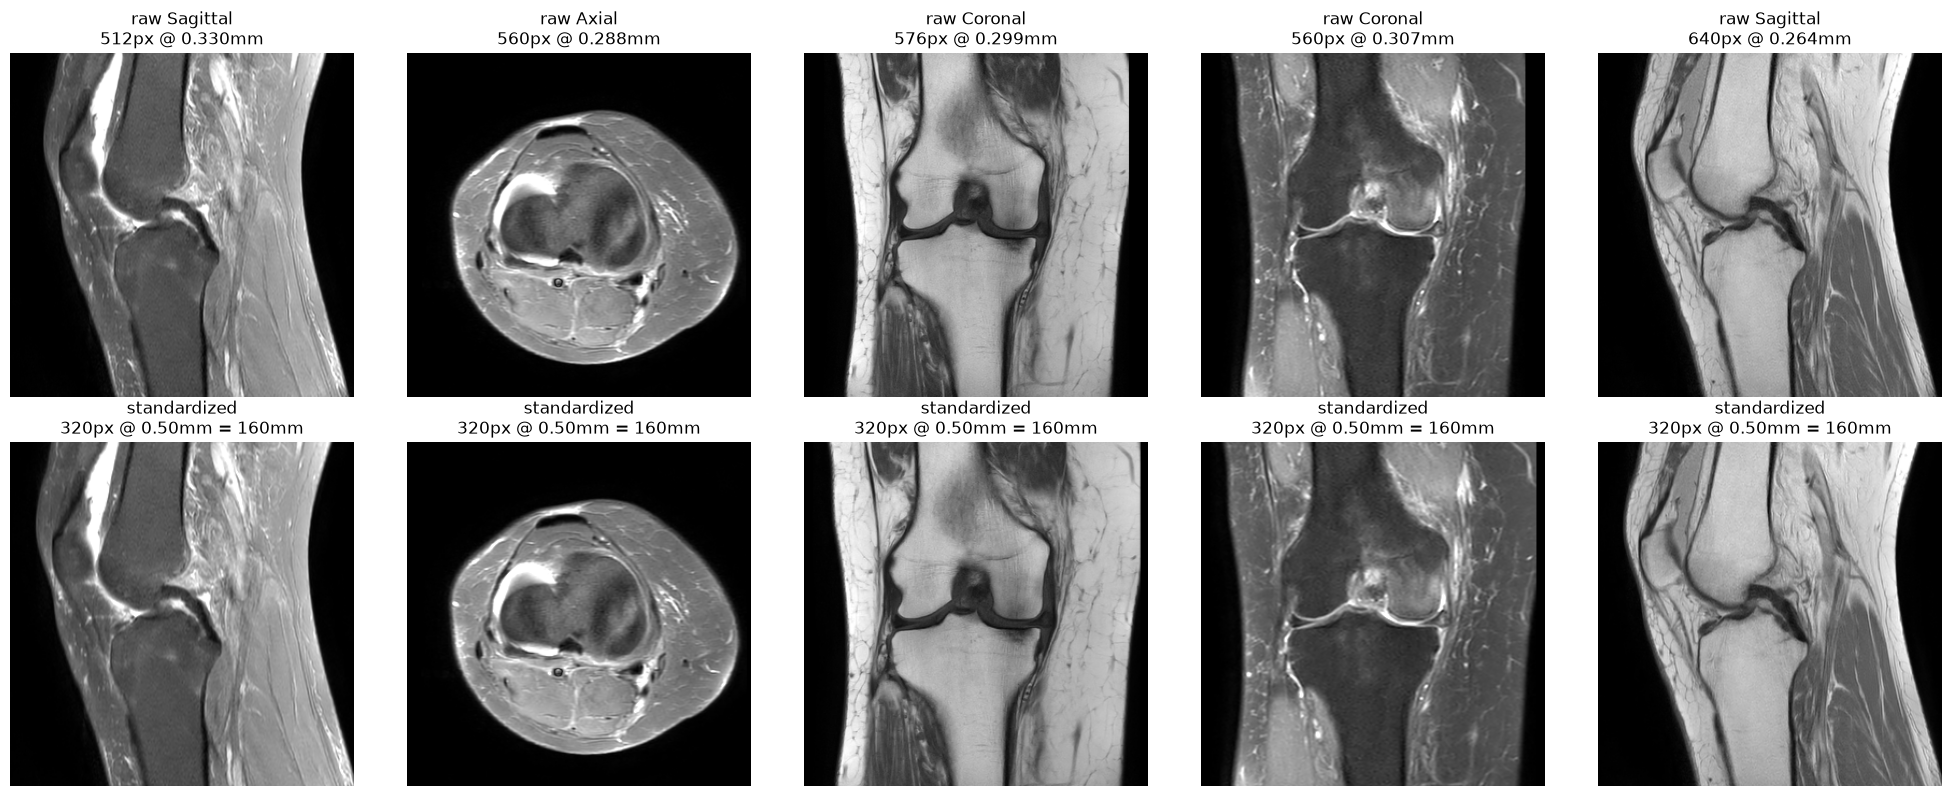

In [18]:
# Every series of the study on one common grid
fig, axes = plt.subplots(2, len(series_paths), figsize=(4 * len(series_paths), 8))

for j, p in enumerate(series_paths):
    s = dt.load_series(p)
    t = dt.standardize(s)
    axes[0, j].imshow(dt.normalize_intensity(s.volume)[s.shape[0] // 2], cmap='gray')
    axes[0, j].set_title(f'raw {s.plane}\n{s.shape[1]}px @ {s.spacing[1]:.3f}mm')
    axes[1, j].imshow(t.volume[t.shape[0] // 2], cmap='gray')
    axes[1, j].set_title(f'standardized\n{t.shape[1]}px @ {t.spacing[1]:.2f}mm = {t.extent_mm[1]:.0f}mm')
    axes[0, j].axis('off'); axes[1, j].axis('off')

plt.tight_layout()
plt.show()


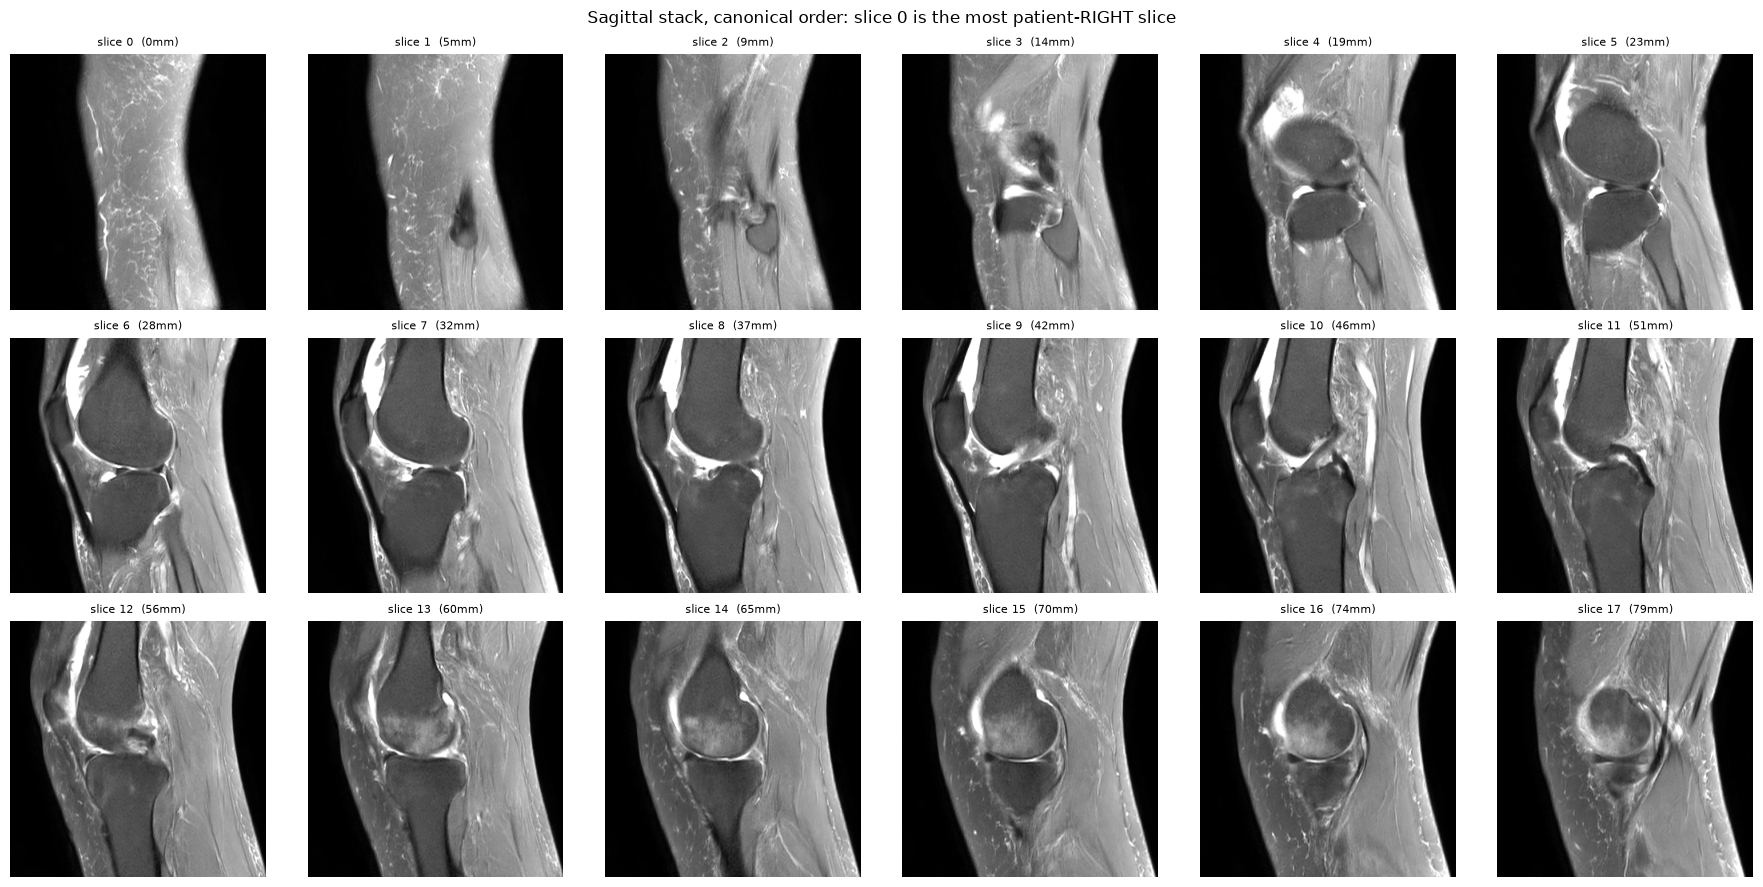

In [19]:
# Sanity check the canonical orientation by eye.
# Sagittal : superior up, anterior left.  Coronal: superior up, patient-left on the right.
# Axial    : anterior up (patella at the top), patient-left on the right.
sag = dt.standardize(dt.load_series(series_paths[0]))

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, ax in enumerate(axes.ravel()):
    if i < sag.shape[0]:
        ax.imshow(sag.volume[i], cmap='gray')
        ax.set_title(f'slice {i}  ({i * sag.spacing[0]:.0f}mm)', fontsize=8)
    ax.axis('off')
plt.suptitle('Sagittal stack, canonical order: slice 0 is the most patient-RIGHT slice')
plt.tight_layout()
plt.show()


### Caveat: medial vs lateral is not recoverable from the pixels alone

Four of the twelve labels are side-specific - `Medial Meniscus`, `Lateral Meniscus`,
`Medial OA`, `Lateral OA`. Which side of a sagittal stack is medial depends on whether
this is a left or a right knee, and **`Laterality` (0020,0060) is blank in this dataset**.

`guess_laterality()` falls back to which side of scanner isocenter the knee sits on
(negative x is the patient's right in LPS). That works when one knee is in the coil, but
it is table positioning, not anatomy - treat it as a hint. Worth checking how stable it
is across studies before any medial/lateral model depends on it.

If it turns out unreliable, the fallbacks are: train the side-specific labels on coronal
series (where medial and lateral are both in frame at once), or let the model learn
laterality from anatomy - the fibula is unmistakably lateral.


In [20]:
# The heuristic uses the centre of the imaged volume, not the corner stored in
# ImagePositionPatient - for coronal and axial series the corner sits ~85mm off to one side.
for p in series_paths:
    hs = dt.read_headers(p)
    centre = dt.volume_center(hs)
    corner = np.mean([[float(h.ImagePositionPatient[i]) for i in range(3)] for h in hs], axis=0)
    print(f'{p.name[-12:]}  {dt.detect_plane(hs[0]):<9} '
          f'corner x {corner[0]:8.1f}   centre x {centre[0]:8.1f}  -> {dt.guess_laterality(hs)}')


715412333772  Sagittal  corner x   -111.0   centre x   -109.0  -> R


927426543265  Axial     corner x   -195.5   centre x   -107.4  -> R


293168736174  Coronal   corner x   -191.1   centre x   -105.9  -> R


147390476697  Coronal   corner x   -191.1   centre x   -105.9  -> R


038670363546  Sagittal  corner x   -111.0   centre x   -109.0  -> R


<a id="5"></a>
## 5. One sequence, loaded by hand

`dt.load_series()` + `dt.standardize()` is two lines. This section is the same thing
unrolled, so every place a decision gets made is visible and labelled. Four knobs get
turned, each marked **KNOB** below:

| knob | comes from | what happens |
|---|---|---|
| **slice order** | `ImagePositionPatient` projected on the normal | sort the files |
| **orientation** | `ImageOrientationPatient` direction cosines | detect plane, then flip axes |
| **pixel ratio** | `PixelSpacing` + measured slice step | resample in-plane, crop to a fixed grid |
| **intensity** | `RescaleSlope`/`Intercept`, then volume percentiles | rescale, then normalize |

The last cell asserts the hand-rolled result is bit-identical to the library call.


### Step 0 - point at one series folder


In [21]:
from scipy import ndimage

series_dir = series_paths[0]          # the sagittal PD fat-sat series
files = sorted(series_dir.glob('*.dcm'))

print(series_dir)
print(len(files), 'files, one per slice')
print('first filename:', files[0].name)
print('  ^ a random UID - carries no position information at all')


/mnt/c/datasets/Knees/1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260/1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772
22 files, one per slice
first filename: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm
  ^ a random UID - carries no position information at all


### Step 1 - headers first, pixels later

Geometry decides how the pixels get assembled, so read the cheap part first.


In [22]:
hdrs = [pydicom.dcmread(f, stop_before_pixels=True) for f in files]
h0 = hdrs[0]
print('plane hint from the protocol name:', h0.SeriesDescription)
print('grid:', h0.Rows, 'x', h0.Columns, '| stored as', h0.BitsStored, 'bit')


plane hint from the protocol name: DP SPIR CS_SAG
grid: 512 x 512 | stored as 12 bit


### Step 2 - KNOB: orientation, part 1 (which plane is this?)

Split `ImageOrientationPatient` into its two direction cosines and cross them. The
dominant axis of the result names the plane. Nothing else in the file states it.


In [23]:
iop = np.asarray(h0.ImageOrientationPatient, dtype=float)
col_dir = iop[:3]      # direction the COLUMN index advances (left to right across a row)
row_dir = iop[3:]      # direction the ROW index advances (top to bottom down a column)
normal  = np.cross(col_dir, row_dir)

print('col_dir', np.round(col_dir, 3), '-> mostly +y = posterior')
print('row_dir', np.round(row_dir, 3), '-> mostly -z = inferior')
print('normal ', np.round(normal, 3), '-> mostly -x = right-to-left')
print()

axis  = int(np.argmax(np.abs(normal)))
plane = dt.PLANE_BY_AXIS[axis]
print(f'dominant axis {axis} -> plane = {plane}')


col_dir [-0.033  0.999  0.021] -> mostly +y = posterior
row_dir [ 0.058  0.023 -0.998] -> mostly -z = inferior
normal  [-0.998 -0.032 -0.059] -> mostly -x = right-to-left

dominant axis 0 -> plane = Sagittal


### Step 3 - KNOB: slice order

Project every slice's `ImagePositionPatient` onto the normal. That number is how far
along the stack the slice physically sits, and sorting on it is the only ordering the
file format actually guarantees.


In [24]:
proj = np.array([float(np.dot(np.asarray(h.ImagePositionPatient, float), normal))
                 for h in hdrs])

print('projections in FILENAME order (note the jumps):')
print(np.round(proj, 1))

order = np.argsort(proj)
hdrs  = [hdrs[i] for i in order]      # <-- the actual reordering
proj  = proj[order]

print()
print('projections in POSITION order:')
print(np.round(proj, 1))
print()
print('step between slices:', np.round(np.diff(proj), 4))


projections in FILENAME order (note the jumps):
[ 79.6 102.8  70.3  65.7  98.1 112.  116.7 130.6 144.5 121.3 139.8 158.4
  88.9  93.5 149.1 125.9 153.8 107.4  84.2  61.1 135.2  75. ]

projections in POSITION order:
[ 61.1  65.7  70.3  75.   79.6  84.2  88.9  93.5  98.1 102.8 107.4 112.
 116.7 121.3 125.9 130.6 135.2 139.8 144.5 149.1 153.8 158.4]

step between slices: [4.6345 4.6346 4.6345 4.6346 4.6345 4.6346 4.6345 4.6345 4.6346 4.6345
 4.6346 4.6345 4.6346 4.6345 4.6345 4.6346 4.6346 4.6345 4.6346 4.6346
 4.6346]


### Step 4 - KNOB: pixel ratio (measure it before you touch anything)

Two ratios, and they behave completely differently.

**In-plane aspect** `PixelSpacing[0] / PixelSpacing[1]` is 1.0 here - square pixels, nothing
to correct. Check it anyway; it is not guaranteed.

**Through-plane anisotropy** is slice step over in-plane spacing, and it is 14x. Note the
step is measured from Step 3, *not* read from `SliceThickness` - that tag says 3.4mm and
ignores the 1.2mm gap between slabs.


In [25]:
row_mm, col_mm = (float(v) for v in h0.PixelSpacing)   # [between rows, between cols]
slice_mm = float(np.median(np.diff(proj)))

print(f'row spacing    {row_mm:.4f} mm')
print(f'col spacing    {col_mm:.4f} mm')
print(f'in-plane aspect {row_mm / col_mm:.3f}   <- 1.0, square pixels, no correction needed')
print()
print(f'slice step     {slice_mm:.3f} mm  (measured)')
print(f'SliceThickness {float(h0.SliceThickness):.3f} mm  (tag - excludes the gap, do not use)')
print(f'anisotropy     {slice_mm / row_mm:.1f}x')


row spacing    0.3301 mm
col spacing    0.3301 mm
in-plane aspect 1.000   <- 1.0, square pixels, no correction needed

slice step     4.635 mm  (measured)
SliceThickness 3.400 mm  (tag - excludes the gap, do not use)
anisotropy     14.0x


#### Why the anisotropy matters the moment you leave the acquired plane

Inside a slice, 14x anisotropy is invisible - you never cross it. Cut *through* the stack
and it is the whole picture. Below, the same reformatted cut through the sagittal volume,
drawn twice: once assuming square voxels, once with `aspect=slice_mm/col_mm`.

Anything that reslices, renders in 3D, or measures a distance across slices has to carry
this number. It is exactly why `standardize()` resamples rows and columns but leaves the
slice axis alone - and it is what the PyVista volume rendering will need too.


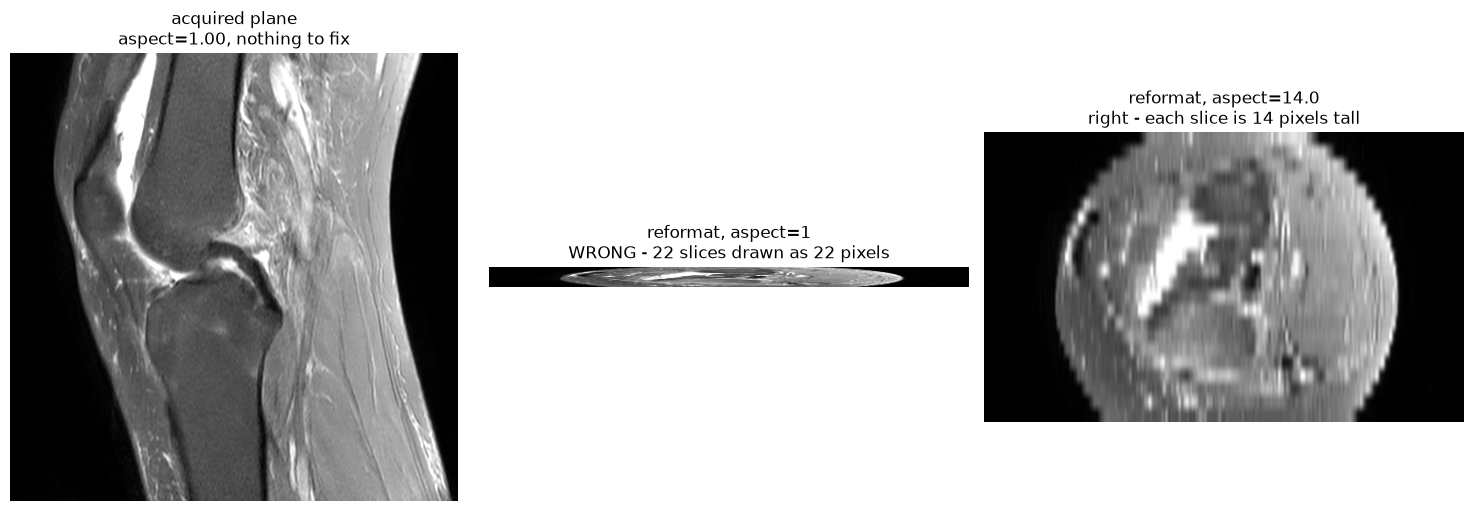

In [26]:
preview = dt.load_series(series_dir)
pv = dt.normalize_intensity(preview.volume)
cut = pv[:, pv.shape[1] // 2, :]        # one row from every slice = a reformatted plane

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(pv[len(pv) // 2], cmap='gray', aspect=row_mm / col_mm)
ax[0].set_title(f'acquired plane\naspect={row_mm / col_mm:.2f}, nothing to fix')
ax[1].imshow(cut, cmap='gray', aspect=1)
ax[1].set_title('reformat, aspect=1\nWRONG - 22 slices drawn as 22 pixels')
ax[2].imshow(cut, cmap='gray', aspect=slice_mm / col_mm)
ax[2].set_title(f'reformat, aspect={slice_mm / col_mm:.1f}\nright - each slice is 14 pixels tall')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


### Step 5 - read the pixels, and KNOB: value scale

`RescaleSlope`/`RescaleIntercept` convert stored integers to the real values. On MR the
result is still arbitrary units, but the slope differs *per series* on Philips, so skipping
it makes two series of the same knee quietly incomparable.


In [27]:
slices = []
for h in hdrs:                              # hdrs is now in position order
    d = pydicom.dcmread(h.filename)         # full read this time - we want pixels
    px = d.pixel_array.astype(np.float32)
    px = px * float(d.RescaleSlope) + float(d.RescaleIntercept)
    slices.append(px)

volume = np.stack(slices)                   # (slices, rows, cols)

print('volume', volume.shape, volume.dtype)
print(f'rescaled range 0 - {volume.max():.1f}   (slope {float(h0.RescaleSlope):.5f})')


volume (22, 512, 512) float32
rescaled range 0 - 2693.0   (slope 2.55507)


### Step 6 - KNOB: orientation, part 2 (flip to a canonical direction)

The plane is known, but the array could still be mirrored or back-to-front. Compare each
of the three axes against the target direction for this plane and flip the ones pointing
the wrong way.

Flips only - never a transpose. A transpose would reorder the axes and silently desync
the `(slice_mm, row_mm, col_mm)` tuple from the array it describes.


In [28]:
target = np.asarray(dt.CANONICAL_DIRS[plane], dtype=float)
actual = np.stack([normal, row_dir, col_dir])       # slice axis, row axis, col axis
names  = ['slice', 'row', 'col']

for a in range(3):
    dot = float(np.dot(actual[a], target[a]))
    print(f'{names[a]:<6} actual {np.round(actual[a], 2)}  target {target[a]}  '
          f'dot {dot:+.2f}  -> {"FLIP" if dot < 0 else "keep"}')
    if dot < 0:
        volume = np.flip(volume, axis=a)

volume = np.ascontiguousarray(volume)
print()
print('after canonicalizing: slice 0 is the most patient-RIGHT slice, row 0 is superior,')
print('col 0 is anterior. Same convention for every sagittal series, any scanner.')


slice  actual [-1.   -0.03 -0.06]  target [1. 0. 0.]  dot -1.00  -> FLIP
row    actual [ 0.06  0.02 -1.  ]  target [ 0.  0. -1.]  dot +1.00  -> keep
col    actual [-0.03  1.    0.02]  target [0. 1. 0.]  dot +1.00  -> keep

after canonicalizing: slice 0 is the most patient-RIGHT slice, row 0 is superior,
col 0 is anterior. Same convention for every sagittal series, any scanner.


### Step 7 - KNOB: pixel ratio, adjusted

Resample rows and columns to a fixed **millimetres per pixel**, then crop or pad to a fixed
pixel count. Two steps on purpose:

- the zoom fixes *physical scale* - a 10mm osteophyte is 20 pixels in every series
- the crop fixes *array shape* so volumes stack, without rescaling anatomy a second time

A single `resize(320, 320)` would collapse both into one operation and destroy the first
one, because these five series run 0.264 to 0.331 mm/px.

The slice axis is deliberately untouched - interpolating across a 4.6mm gap invents tissue.


In [29]:
TARGET_MM = 0.5
OUT_HW    = (320, 320)

zoom = (1.0, row_mm / TARGET_MM, col_mm / TARGET_MM)     # 1.0 = leave slices alone
print('zoom factors (slice, row, col):', np.round(zoom, 4))

volume = ndimage.zoom(volume, zoom, order=1, mode='nearest').astype(np.float32)
print('after resample:', volume.shape, f'at {TARGET_MM} mm/px '
      f'= {volume.shape[1] * TARGET_MM:.0f} mm of anatomy')

volume = dt.center_crop_pad(volume, OUT_HW)
print('after crop/pad:', volume.shape, f'= {OUT_HW[0] * TARGET_MM:.0f} mm of anatomy')

spacing = (slice_mm, TARGET_MM, TARGET_MM)
print('spacing now   :', np.round(spacing, 3), 'mm')


zoom factors (slice, row, col): [1.     0.6602 0.6602]
after resample: (22, 338, 338) at 0.5 mm/px = 169 mm of anatomy
after crop/pad: (22, 320, 320) = 160 mm of anatomy
spacing now   : [4.635 0.5   0.5  ] mm


### Step 8 - KNOB: intensity

Last, so the percentiles are taken on exactly the voxels the model will see. Per volume,
1st to 99th percentile, clipped - not `WindowCenter`/`WindowWidth`, which drift from slice
to slice inside one series.


In [30]:
lo, hi = np.percentile(volume, [1, 99])
print(f'1st percentile {lo:8.1f}   99th percentile {hi:8.1f}   max {volume.max():8.1f}')

volume = np.clip((volume - lo) / (hi - lo), 0, 1).astype(np.float32)
print('final:', volume.shape, volume.dtype, f'range {volume.min():.1f} - {volume.max():.1f}')


1st percentile      0.0   99th percentile   1565.8   max   2638.3


final: (22, 320, 320) float32 range 0.0 - 1.0


### Step 9 - the payoff

The two-line version does exactly this and nothing more.


In [31]:
library = dt.standardize(dt.load_series(series_dir), target_mm=TARGET_MM, out_hw=OUT_HW)

print('by hand :', volume.shape, volume.dtype)
print('library :', library.volume.shape, library.volume.dtype)
print()
print('identical:', np.array_equal(volume, library.volume))
assert np.array_equal(volume, library.volume)


by hand : (22, 320, 320) float32
library : (22, 320, 320) float32

identical: True


### Where each knob lives in `dicom_tools.py`

| knob | function | when you would change it |
|---|---|---|
| slice order | `sort_by_position` | never - geometry is geometry |
| plane detection | `detect_plane` | never |
| axis flips | `_to_canonical` via `CANONICAL_DIRS` | if you want a different display convention |
| in-plane scale | `resample_in_plane(target_mm=)` | 0.5mm is a choice; 0.7 halves the memory |
| output grid | `center_crop_pad(out_hw=)` | 320 = 160mm FOV; 256 = 128mm, crops the shafts |
| slice count | `resample_slices(n_slices=)` | only if the model needs fixed depth |
| intensity | `normalize_intensity(p_low, p_high)` | 1/99 is a choice; 0.5/99.5 keeps more range |


<a id="6"></a>
## 6. Scaling up

`build_manifest()` sweeps every series with header-only reads and returns one row of
geometry each. Build it once, cache it to CSV, and use it to decide which series feed
which model - it joins straight back to `train.csv` on `StudyInstanceUID`.

With 4,407 studies at ~5 series each, expect ~22,000 rows. The header-only read is what
makes that tractable.


In [32]:
manifest = dt.build_manifest()
print(manifest.shape)
manifest


(5, 16)


,StudyInstanceUID,SeriesInstanceUID,plane,n_slices,rows,cols,row_mm,col_mm,slice_mm,thickness,series_description,tr,te,scan_options,manufacturer,laterality_guess
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,Sagittal,22,512,512,0.330078,0.330078,4.634557,3.4,DP SPIR CS_SAG,4244.640625,22.0,FS,Philips Healthcare,R
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,Axial,18,560,560,0.287712,0.287712,7.718183,4.0,STIR CS_ AX,2599.101074,20.0,OTHER,Philips Healthcare,R
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,Coronal,16,576,576,0.298910,0.298910,6.594822,4.0,T1_TSE_CS,643.492004,15.0,OTHER,Philips Healthcare,R
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,Coronal,16,560,560,0.307450,0.307450,6.594822,4.0,DP SPAIR_CS,2000.000000,15.0,FS,Philips Healthcare,R
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,Sagittal,22,640,640,0.264062,0.264062,4.634557,3.0,DP CS_SAG,3493.437256,10.0,OTHER,Philips Healthcare,R


In [33]:
# What varies across the dataset - re-run once more studies are downloaded
print(manifest.groupby('plane').agg(
    n=('n_slices', 'size'),
    slices=('n_slices', 'mean'),
    px=('rows', 'mean'),
    in_plane_mm=('row_mm', 'mean'),
    slice_mm=('slice_mm', 'mean'),
).round(3))

# manifest.to_csv('../data/series_manifest.csv', index=False)


          n  slices     px  in_plane_mm  slice_mm
plane                                            
Axial     1    18.0  560.0        0.288     7.718
Coronal   2    16.0  568.0        0.303     6.595
Sagittal  2    22.0  576.0        0.297     4.635


## Where this leaves the image pipeline

Working now:

- geometry-sorted, canonically-oriented volumes from any series folder
- plane detection that agrees with the Kaggle labels on every series checked
- one common grid (0.5 mm/px, 320x320) and intensity scale across sequences
- a header-only manifest that scales to the full 569 GB

Open questions, roughly in priority order:

1. **Laterality** - see the caveat in section 4. Blocks the medial/lateral labels.
2. **Which series feeds which label.** ACL is a sagittal call, meniscus is sagittal +
   coronal, effusion shows best on fluid-sensitive sequences. `train_series.csv` gives
   `Fluid_Sensitive` and `Fat_Suppression` per series - the routing is already in the data.
3. **Variable slice count** - decide whether the model takes a variable stack or whether
   `n_slices=` gets set.
4. **Caching** - decoding DICOM on every epoch is wasteful. Write standardized volumes
   out as `.npy` once and train off those.
5. **Multi-frame files** - all slices here are single-frame. If any enhanced multi-frame
   DICOM turns up elsewhere in the dataset, `load_series` will need a separate path for it.
